# Analítica de Datos: Gráficos Avanzados y Poco Comunes

**Parte 2 — Mapas, jerarquías, flujos y otras visualizaciones especializadas**

Sergio Alejandro Holguín García

---

En la **Parte 1** vimos los gráficos clásicos (barras, líneas, pastel, dispersión, etc.). Esta segunda parte cubre visualizaciones menos habituales pero muy potentes cuando el dato lo pide.

## Contenido

1. Mapas geográficos
   - Mapa coroplético mundial
   - Mapa de puntos (ciudades de Colombia)
   - Mapa de densidad (heatmap geográfico)
2. Jerarquías
   - Treemap
   - Sunburst
3. Distribuciones avanzadas
   - Violin plot
   - Ridgeline plot (joyplot)
4. Comparación multi-variable
   - Radar chart
   - Bubble chart
5. Flujos y procesos
   - Diagrama de Sankey
   - Gráfico de cascada (waterfall)
   - Gráfico de embudo (funnel)
6. Análisis especializados
   - Diagrama de Pareto
   - Hexbin plot
   - Calendar heatmap (estilo GitHub)

> **Nota técnica:** los mapas y algunos gráficos jerárquicos usan **Plotly**, una librería que produce gráficos **interactivos** (puedes hacer zoom, hover, filtrar). Si los ejes aparecen vacíos al abrir el notebook, asegúrate de tener `plotly` instalado (`pip install plotly`) y de estar ejecutando en Jupyter.

---

## Configuración del entorno

In [2]:
# Si alguna librería no está instalada, descomenta la siguiente línea:
!pip install plotly squarify

# Librerías base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import seaborn as sns

# Para treemaps con matplotlib
import squarify

# Para gráficos interactivos (mapas, sankey, sunburst, etc.)
import plotly.express as px
import plotly.graph_objects as go

# Configuración estética
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


---
## 1. Mapas geográficos

Los mapas son una de las formas más intuitivas de mostrar datos cuando la dimensión geográfica importa: ventas por país, casos de una enfermedad por departamento, ubicación de tiendas, etc.

### 1.1 Mapa coroplético mundial

**¿Qué es?** Un mapa donde cada región (país, departamento, estado) se colorea según un valor numérico.

**¿Cuándo usarlo?** Para comparar magnitudes entre territorios. Funciona muy bien para PIB por país, esperanza de vida, densidad poblacional, etc.

**Ejemplo:** esperanza de vida por país en 2007 (dataset Gapminder, viene incluido con plotly).

In [3]:
# Plotly trae datasets de ejemplo. Gapminder contiene indicadores socioeconómicos por país.
df_paises = px.data.gapminder().query('year == 2007')

print('Primeras filas del dataset:')
df_paises.head()

Primeras filas del dataset:


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG,4
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
35,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA,12
47,Angola,Africa,2007,42.731,12420476,4797.231267,AGO,24
59,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG,32


In [4]:
# Mapa coroplético: cada país coloreado según esperanza de vida
fig = px.choropleth(
    df_paises,
    locations='iso_alpha',                # Códigos ISO de cada país (ej: COL, USA)
    color='lifeExp',                       # Variable que define el color
    hover_name='country',                  # Texto que aparece al pasar el mouse
    color_continuous_scale='Viridis',      # Paleta de colores secuencial
    title='Esperanza de vida por país (2007)',
    labels={'lifeExp': 'Esperanza de vida (años)'},
)

# Ajustes de presentación
fig.update_layout(
    width=900, height=500,
    margin=dict(l=10, r=10, t=50, b=10),
)

fig.show()

**Interpretación:** Los países con mayor esperanza de vida (Japón, Europa Occidental, Australia, Canadá) aparecen en amarillo. África Subsahariana muestra los valores más bajos. Pasa el mouse por encima de cada país para ver el dato exacto.

### 1.2 Mapa de puntos (scatter geográfico)

**¿Qué es?** Cada punto se ubica en una coordenada geográfica (latitud, longitud). El tamaño y/o color del punto representan otra variable.

**¿Cuándo usarlo?** Para mostrar ubicaciones específicas: tiendas, clientes, eventos, ciudades.

**Ejemplo:** principales ciudades de Colombia, con el tamaño del punto proporcional a la población.

In [5]:
# Datos reales (aproximados) de las principales ciudades de Colombia
ciudades_co = pd.DataFrame({
    'ciudad':     ['Bogotá', 'Medellín', 'Cali', 'Barranquilla', 'Cartagena',
                   'Bucaramanga', 'Pereira', 'Manizales', 'Santa Marta', 'Cúcuta'],
    'lat':        [4.7110, 6.2442, 3.4516, 10.9685, 10.3910,
                   7.1254, 4.8133, 5.0689, 11.2408, 7.8939],
    'lon':        [-74.0721, -75.5812, -76.5320, -74.7813, -75.4794,
                   -73.1198, -75.6961, -75.5174, -74.1990, -72.5078],
    'poblacion':  [7900000, 2530000, 2200000, 1230000, 1030000,
                   530000, 470000, 400000, 500000, 700000],
})

fig = px.scatter_geo(
    ciudades_co,
    lat='lat', lon='lon',
    size='poblacion',                      # tamaño del punto = población
    color='poblacion',                     # color también según población
    hover_name='ciudad',
    hover_data={'poblacion': ':,', 'lat': False, 'lon': False},
    color_continuous_scale='Plasma',
    size_max=40,
    title='Principales ciudades de Colombia por población',
    projection='mercator',                 # proyección del mapa
)

# Centrar el mapa en Colombia
fig.update_geos(
    visible=True,
    resolution=50,
    showcountries=True, countrycolor='gray',
    showland=True,      landcolor='whitesmoke',
    lataxis_range=[-5, 14],
    lonaxis_range=[-80, -66],
)
fig.update_layout(width=800, height=600, margin=dict(l=0, r=0, t=50, b=0))

fig.show()

**Interpretación:** Bogotá domina visiblemente como mayor punto, seguida de Medellín y Cali. Los puntos más pequeños (Manizales, Pereira) muestran el peso relativo de las ciudades intermedias.

### 1.3 Mapa de densidad (heatmap geográfico)

**¿Qué es?** Mapa que pinta zonas más calientes donde hay mayor concentración de eventos.

**¿Cuándo usarlo?** Cuando tienes muchísimos puntos y un scatter quedaría saturado: ubicaciones de pedidos, accidentes de tráfico, llamadas de emergencia.

**Ejemplo:** simulación de ubicaciones de entregas a domicilio en Bogotá.

In [6]:
# Simulamos 2.000 entregas concentradas en varias zonas de Bogotá
n_entregas = 2000

# Tres clústeres alrededor de zonas reales de la ciudad
centros = [(4.65, -74.10), (4.71, -74.07), (4.75, -74.05)]
lats, lons = [], []

for centro in centros:
    lats.extend(np.random.normal(centro[0], 0.015, n_entregas // 3))
    lons.extend(np.random.normal(centro[1], 0.020, n_entregas // 3))

df_entregas = pd.DataFrame({'lat': lats, 'lon': lons})

fig = px.density_map(
    df_entregas,
    lat='lat', lon='lon',
    radius=10,                              # radio de difuminado
    center=dict(lat=4.71, lon=-74.07),     # centro inicial del mapa
    zoom=10,
    map_style='open-street-map',           # mapa base gratuito (sin token)
    color_continuous_scale='YlOrRd',
    title='Concentración de entregas en Bogotá (simulación)',
)
fig.update_layout(width=800, height=550, margin=dict(l=0, r=0, t=50, b=0))

fig.show()

**Interpretación:** las zonas rojas indican mayor densidad de entregas. Es ideal para decisiones logísticas como dónde ubicar bodegas o motorizados.

---
## 2. Jerarquías

Cuando los datos tienen una estructura de **categorías dentro de categorías** (continente → país → ciudad, o departamento → área → equipo), los gráficos jerárquicos son la mejor opción.

### 2.1 Treemap (mapa de árbol)

**¿Qué es?** Divide un rectángulo grande en rectángulos más pequeños, donde cada uno tiene un área proporcional al valor que representa.

**¿Cuándo usarlo?** Para mostrar **partes de un todo** cuando hay muchas categorías o jerarquía. Es una gran alternativa al pastel cuando este se vuelve ilegible.

**Ejemplo:** distribución del gasto familiar mensual.

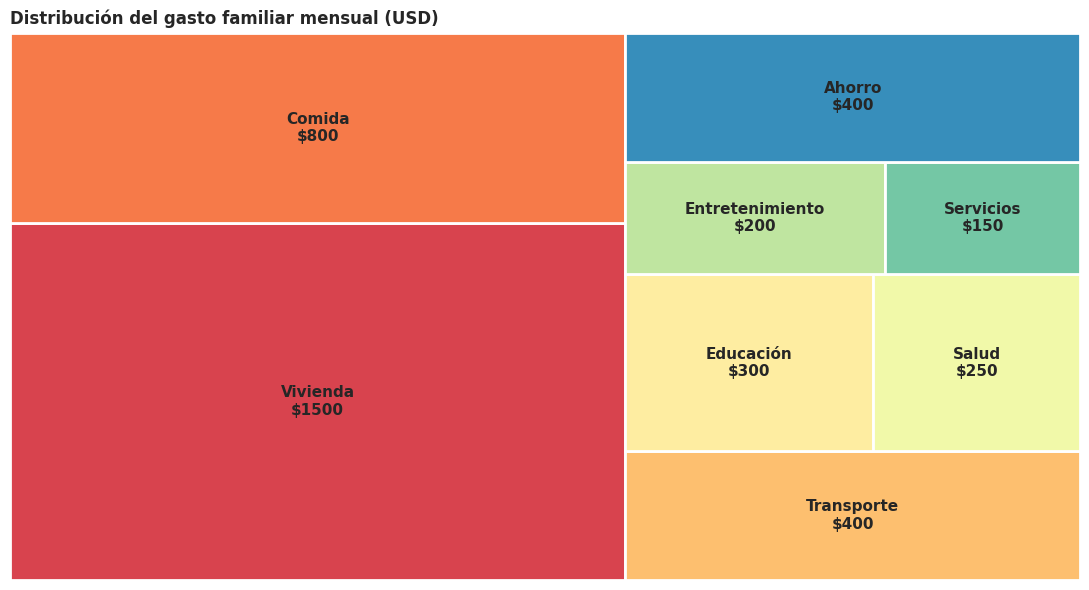

In [7]:
# Datos del ejemplo
categorias = ['Vivienda', 'Comida', 'Transporte', 'Educación',
              'Salud', 'Entretenimiento', 'Servicios', 'Ahorro']
valores    = [1500, 800, 400, 300, 250, 200, 150, 400]

# Etiquetas que muestran categoría + valor
etiquetas = [f'{c}\n${v}' for c, v in zip(categorias, valores)]

# Paleta de colores agradable
colores = sns.color_palette('Spectral', len(categorias))

fig, ax = plt.subplots(figsize=(11, 6))

# squarify.plot calcula automáticamente las posiciones de los rectángulos
squarify.plot(
    sizes=valores,
    label=etiquetas,
    color=colores,
    text_kwargs={'fontsize': 11, 'fontweight': 'bold'},
    edgecolor='white',
    linewidth=2,
    ax=ax,
)

ax.set_title('Distribución del gasto familiar mensual (USD)', loc='left')
ax.axis('off')   # los ejes no aportan información en un treemap
plt.tight_layout()
plt.show()

**Interpretación:** la vivienda concentra el mayor gasto (rectángulo más grande). De un vistazo se compara la importancia relativa de cada rubro.

### 2.2 Sunburst (gráfico de explosión solar)

**¿Qué es?** Como un pastel, pero con **anillos concéntricos** que muestran niveles jerárquicos. El anillo interno = nivel superior, los externos = subniveles.

**¿Cuándo usarlo?** Para visualizar jerarquías de forma circular, especialmente cuando interesa ver tanto el nivel agregado como el detalle.

**Ejemplo:** ventas por continente y país.

In [8]:
# Datos jerárquicos: continente -> país -> ventas
df_sunburst = pd.DataFrame({
    'continente': ['América', 'América', 'América', 'América',
                   'Europa', 'Europa', 'Europa',
                   'Asia', 'Asia', 'Asia'],
    'pais':       ['Colombia', 'México', 'EEUU', 'Brasil',
                   'España', 'Francia', 'Alemania',
                   'Japón', 'China', 'India'],
    'ventas':     [120, 90, 350, 180,
                   140, 200, 220,
                   180, 280, 150],
})

fig = px.sunburst(
    df_sunburst,
    path=['continente', 'pais'],     # jerarquía: de afuera hacia adentro
    values='ventas',
    color='ventas',
    color_continuous_scale='Blues',
    title='Ventas por continente y país',
)
fig.update_layout(width=700, height=600, margin=dict(l=10, r=10, t=50, b=10))

fig.show()

**Interpretación:** el anillo interno muestra el peso de cada continente; el externo, el aporte de cada país. **Haz clic en cualquier sector** para hacer zoom interactivo.

---
## 3. Distribuciones avanzadas

### 3.1 Violin plot

**¿Qué es?** Una mezcla entre box plot y histograma: muestra la **forma de la distribución** además de los cuartiles. El ancho de la "violín" indica la densidad de datos en cada valor.

**¿Cuándo usarlo?** Cuando un box plot no te dice toda la verdad: dos grupos pueden tener la misma mediana pero distribuciones muy diferentes (bimodal vs uniforme), y solo el violin lo revela.

**Ejemplo:** propinas por día de la semana.

/tmp/ipykernel_5637/2637644248.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




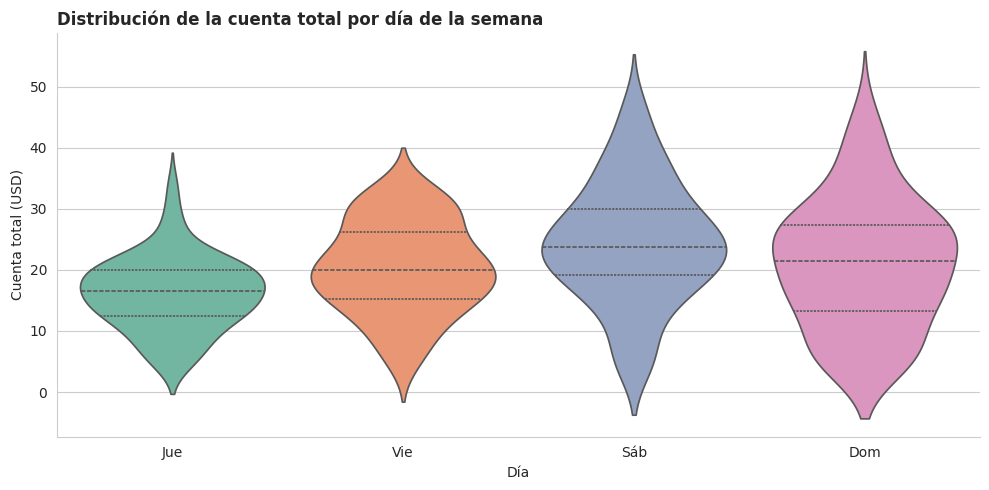

In [9]:
# Generamos un dataset sintético: cuentas totales en un restaurante por día
dias = ['Jue', 'Vie', 'Sáb', 'Dom']
medias_dia = {'Jue': 17, 'Vie': 20, 'Sáb': 25, 'Dom': 23}
desv_dia   = {'Jue':  6, 'Vie':  8, 'Sáb': 12, 'Dom': 10}

datos_tips = []
for dia in dias:
    cuentas = np.random.normal(medias_dia[dia], desv_dia[dia], 60)
    cuentas = np.clip(cuentas, 5, 60)   # acotar a un rango realista
    for c in cuentas:
        datos_tips.append({'day': dia, 'total_bill': c})

tips = pd.DataFrame(datos_tips)

fig, ax = plt.subplots(figsize=(10, 5))

sns.violinplot(
    data=tips,
    x='day', y='total_bill',
    palette='Set2',
    inner='quartile',     # dibuja líneas de cuartiles dentro de la violin
    ax=ax,
)

ax.set_title('Distribución de la cuenta total por día de la semana', loc='left')
ax.set_xlabel('Día')
ax.set_ylabel('Cuenta total (USD)')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretación:** Los fines de semana (Sat, Sun) muestran cuentas más altas y mayor variabilidad. Los "abultamientos" del violín revelan zonas de mayor concentración de valores.

### 3.2 Ridgeline plot (joyplot)

**¿Qué es?** Apila varias distribuciones (una por categoría) ligeramente solapadas. Llamado así por la portada del álbum *Unknown Pleasures* de Joy Division.

**¿Cuándo usarlo?** Para comparar **muchas distribuciones** sin saturar el gráfico. Es elegante y muy compacto.

**Ejemplo:** distribución de calificaciones por carrera universitaria.

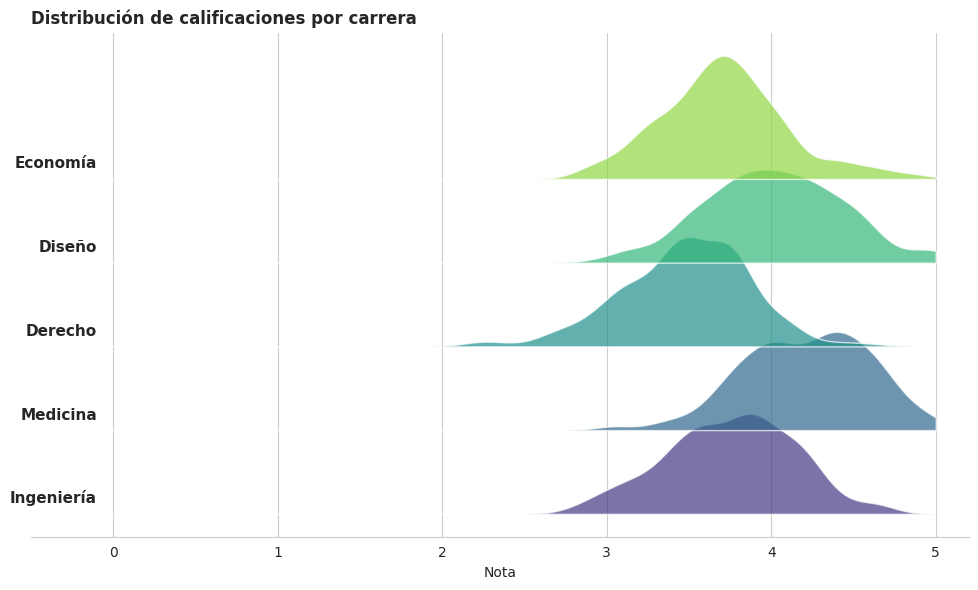

In [10]:
# Simulamos calificaciones para 5 carreras
carreras = ['Ingeniería', 'Medicina', 'Derecho', 'Diseño', 'Economía']
medias   = [3.8, 4.2, 3.5, 4.0, 3.7]

datos_ridge = []
for carrera, media in zip(carreras, medias):
    notas = np.random.normal(loc=media, scale=0.4, size=200)
    notas = np.clip(notas, 0, 5)
    for n in notas:
        datos_ridge.append({'carrera': carrera, 'nota': n})

df_ridge = pd.DataFrame(datos_ridge)

# Construimos el ridgeline manualmente con matplotlib
fig, ax = plt.subplots(figsize=(10, 6))

colores = sns.color_palette('viridis', len(carreras))
x_grid  = np.linspace(0, 5, 200)

for i, carrera in enumerate(carreras):
    notas = df_ridge[df_ridge['carrera'] == carrera]['nota']

    # Estimación de densidad por kernel (KDE)
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(notas, bw_method=0.3)
    densidad = kde(x_grid)

    # Cada distribución se desplaza verticalmente
    offset = i * 0.8
    ax.fill_between(x_grid, offset, offset + densidad,
                    color=colores[i], alpha=0.7, edgecolor='white')
    ax.text(-0.1, offset + 0.1, carrera, ha='right', fontsize=11, fontweight='bold')

ax.set_xlabel('Nota')
ax.set_yticks([])
ax.set_title('Distribución de calificaciones por carrera', loc='left')
ax.set_xlim(-0.5, 5.2)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretación:** Medicina tiene las notas más altas concentradas; Derecho muestra la distribución más amplia y desplazada hacia abajo. El formato apilado permite comparar de un vistazo cinco distribuciones distintas.

---
## 4. Comparación multi-variable

### 4.1 Radar chart (gráfico de araña)

**¿Qué es?** Cada eje radial representa una variable distinta. Una línea cerrada conecta los valores de un sujeto a través de todas las variables.

**¿Cuándo usarlo?** Para comparar varios objetos (empleados, productos, equipos) en múltiples dimensiones a la vez.

**Ejemplo:** comparación de habilidades entre dos candidatos a un cargo.

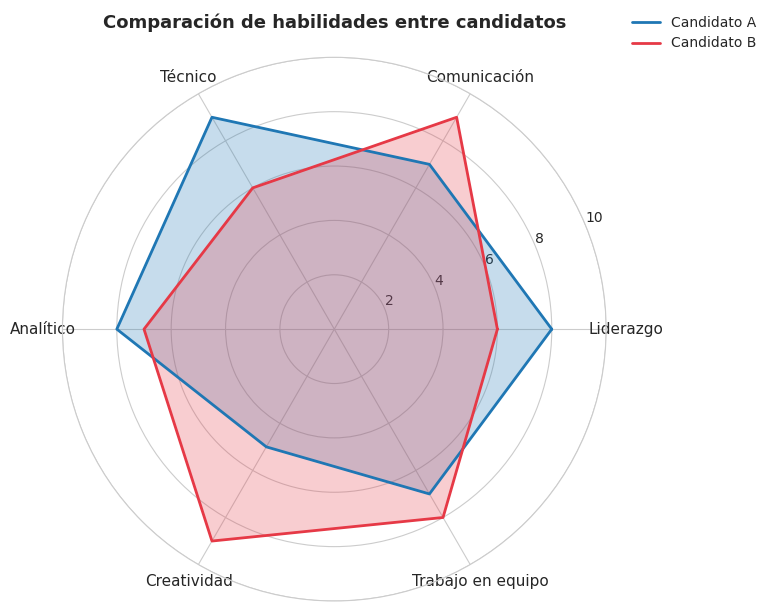

In [11]:
# Habilidades a evaluar (sobre 10)
habilidades = ['Liderazgo', 'Comunicación', 'Técnico', 'Analítico',
               'Creatividad', 'Trabajo en equipo']

candidato_a = [8, 7, 9, 8, 5, 7]
candidato_b = [6, 9, 6, 7, 9, 8]

# Para cerrar el polígono repetimos el primer valor al final
n      = len(habilidades)
angulos = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angulos += angulos[:1]
candidato_a += candidato_a[:1]
candidato_b += candidato_b[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Candidato A
ax.plot(angulos, candidato_a, color='#1f77b4', linewidth=2, label='Candidato A')
ax.fill(angulos, candidato_a, color='#1f77b4', alpha=0.25)

# Candidato B
ax.plot(angulos, candidato_b, color='#e63946', linewidth=2, label='Candidato B')
ax.fill(angulos, candidato_b, color='#e63946', alpha=0.25)

# Etiquetas en cada eje
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(habilidades, fontsize=11)
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_title('Comparación de habilidades entre candidatos\n', fontsize=13)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), frameon=False)

plt.tight_layout()
plt.show()

**Interpretación:** El Candidato A destaca en habilidades técnicas y liderazgo; el B en creatividad y comunicación. La forma del polígono sirve como "huella" del perfil de cada persona.

**Advertencia:** los radar charts son discutidos en la comunidad de visualización porque pueden ser difíciles de leer con muchas variables. Úsalos con un máximo de 6-8 ejes.

### 4.2 Bubble chart

**¿Qué es?** Un scatter plot al que le añadimos una **tercera dimensión** mediante el tamaño del punto (y opcionalmente una cuarta con el color).

**¿Cuándo usarlo?** Cuando quieres mostrar tres o cuatro variables al mismo tiempo.

**Ejemplo:** PIB per cápita vs esperanza de vida, con el tamaño = población y color = continente (clásico de Hans Rosling).

In [12]:
# Reutilizamos el dataset de Gapminder
df_bubble = px.data.gapminder().query('year == 2007')

fig = px.scatter(
    df_bubble,
    x='gdpPercap', y='lifeExp',
    size='pop', color='continent',
    hover_name='country',
    log_x=True,             # eje X en escala logarítmica (PIB varía mucho)
    size_max=60,
    title='PIB per cápita vs Esperanza de vida (2007)',
    labels={'gdpPercap': 'PIB per cápita (USD, escala log)',
            'lifeExp':   'Esperanza de vida (años)',
            'continent': 'Continente'},
)
fig.update_layout(width=900, height=550, margin=dict(l=10, r=10, t=50, b=10))

fig.show()

**Interpretación:** Cuatro variables en un solo gráfico: posición X (PIB), posición Y (esperanza de vida), tamaño (población), color (continente). Se ve claramente la correlación positiva entre riqueza y esperanza de vida, y la distribución por continentes.

---
## 5. Flujos y procesos

### 5.1 Diagrama de Sankey

**¿Qué es?** Muestra **flujos** entre nodos. El ancho de cada flujo es proporcional a la cantidad que se mueve.

**¿Cuándo usarlo?** Para visualizar transferencias: presupuestos que se distribuyen, pasos de un funnel de conversión, migraciones de usuarios entre productos.

**Ejemplo:** flujo de fuentes de tráfico de un sitio web hasta la conversión final.

In [13]:
# Definimos los nodos (todas las etapas)
nodos = ['Google', 'Facebook', 'Instagram', 'Email',     # fuentes (0-3)
         'Landing', 'Producto', 'Carrito',                # etapas intermedias (4-6)
         'Compra', 'Abandono']                            # resultados finales (7-8)

# Definimos los flujos: source -> target con un valor
# Los índices corresponden a la posición en la lista 'nodos'
flujos = dict(
    source = [0, 1, 2, 3,    4, 4,    5, 5,    6, 6],
    target = [4, 4, 4, 4,    5, 8,    6, 8,    7, 8],
    value  = [400, 250, 150, 200,    700, 300,    500, 200,    350, 150],
)

fig = go.Figure(go.Sankey(
    node=dict(
        label=nodos,
        pad=20, thickness=20,
        color=['#4285F4', '#1877F2', '#E1306C', '#EA4335',
               '#999999', '#999999', '#999999',
               '#34A853', '#EA4335'],
    ),
    link=dict(
        source=flujos['source'],
        target=flujos['target'],
        value =flujos['value'],
        color='rgba(150,150,150,0.4)',
    ),
))

fig.update_layout(
    title='Embudo de conversión: del clic a la compra',
    width=900, height=500,
    font=dict(size=12),
)
fig.show()

**Interpretación:** Cada banda muestra el volumen que pasa de una etapa a la siguiente. Las bandas que terminan en "Abandono" indican dónde se está perdiendo más conversión.

### 5.2 Gráfico de cascada (waterfall)

**¿Qué es?** Muestra cómo un valor inicial cambia paso a paso (sumas y restas) hasta llegar a un valor final.

**¿Cuándo usarlo?** Para análisis financieros (de ingresos brutos a netos), variaciones presupuestales, o cualquier descomposición incremental.

**Ejemplo:** del ingreso bruto a la utilidad neta de una empresa.

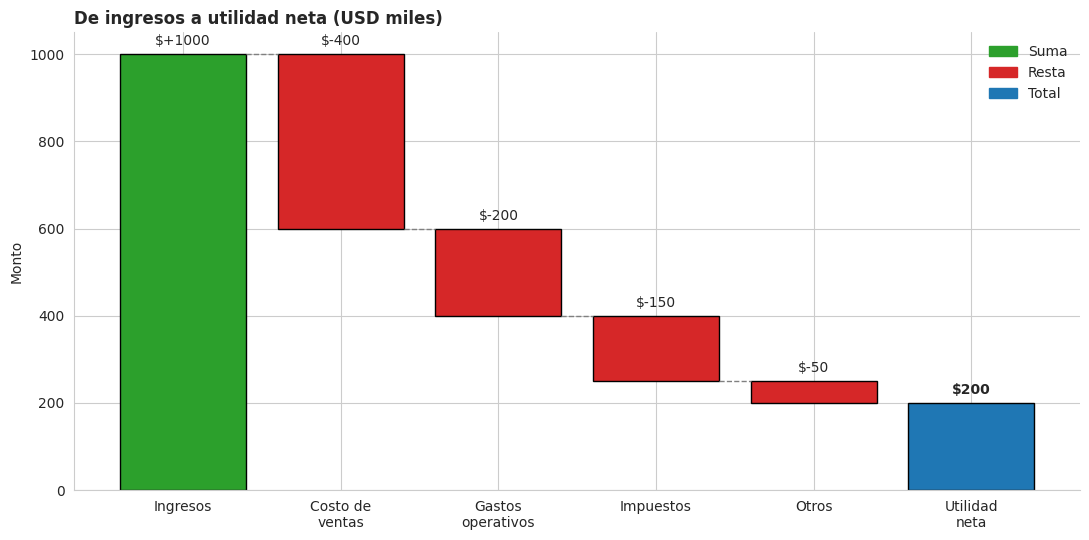

In [14]:
# Datos: cambios sucesivos
etapas  = ['Ingresos', 'Costo de\nventas', 'Gastos\noperativos',
           'Impuestos', 'Otros', 'Utilidad\nneta']
valores = [1000, -400, -200, -150, -50, 200]   # el último es el total acumulado

fig, ax = plt.subplots(figsize=(11, 5.5))

# Calcular las posiciones de cada barra (acumuladas)
acumulado = 0
for i, (etapa, valor) in enumerate(zip(etapas, valores)):
    if i == len(etapas) - 1:
        # Última barra: el total final, parte desde 0
        ax.bar(etapa, valor, color='#1f77b4', edgecolor='black')
        ax.text(i, valor + 20, f'${valor}', ha='center', fontweight='bold')
    else:
        # Barras intermedias: verde si suman, rojo si restan
        color = '#2ca02c' if valor > 0 else '#d62728'
        bottom = acumulado if valor > 0 else acumulado + valor
        ax.bar(etapa, abs(valor), bottom=bottom, color=color, edgecolor='black')
        ax.text(i, bottom + abs(valor) + 20, f'${valor:+}', ha='center')
        acumulado += valor

        # Línea horizontal punteada que conecta con la siguiente barra
        if i < len(etapas) - 2:
            ax.plot([i + 0.4, i + 0.6], [acumulado, acumulado],
                    color='gray', linestyle='--', linewidth=1)

ax.set_title('De ingresos a utilidad neta (USD miles)', loc='left')
ax.set_ylabel('Monto')
ax.axhline(0, color='black', linewidth=0.5)

# Leyenda manual
leyenda = [mpatches.Patch(color='#2ca02c', label='Suma'),
           mpatches.Patch(color='#d62728', label='Resta'),
           mpatches.Patch(color='#1f77b4', label='Total')]
ax.legend(handles=leyenda, frameon=False, loc='upper right')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretación:** Partiendo de USD 1.000 de ingresos, las barras rojas muestran lo que se resta en cada categoría hasta llegar a la utilidad neta de USD 200. Es una excelente forma de explicar visualmente un estado de resultados.

### 5.3 Gráfico de embudo (funnel)

**¿Qué es?** Barras horizontales decrecientes que representan cómo se reduce un volumen en cada etapa de un proceso.

**¿Cuándo usarlo?** Para procesos de conversión: de visitantes a clientes, de candidatos a contratados, de leads a ventas cerradas.

**Ejemplo:** funnel de un proceso de selección.

In [15]:
etapas_funnel = ['Aplicaron', 'Hojas de vida revisadas',
                 'Entrevista inicial', 'Entrevista técnica',
                 'Oferta enviada', 'Contratados']
valores_funnel = [1000, 400, 150, 60, 20, 12]

fig = go.Figure(go.Funnel(
    y=etapas_funnel,
    x=valores_funnel,
    textposition='inside',
    textinfo='value+percent initial',   # muestra valor + % respecto al inicio
    marker=dict(color=['#1f77b4', '#2ca02c', '#ff7f0e',
                       '#d62728', '#9467bd', '#8c564b']),
))

fig.update_layout(
    title='Funnel de proceso de selección',
    width=800, height=500,
    margin=dict(l=10, r=10, t=50, b=10),
)
fig.show()

**Interpretación:** De cada 1.000 candidatos solo 12 son contratados (1,2%). El estrechamiento del embudo permite ver dónde se pierde más gente, dato clave para optimizar el proceso.

---
## 6. Análisis especializados

### 6.1 Diagrama de Pareto

**¿Qué es?** Combina barras (frecuencia de cada categoría, ordenadas de mayor a menor) con una línea que muestra el **porcentaje acumulado**.

**¿Cuándo usarlo?** Para aplicar la **regla 80/20**: el 80% de los problemas suele venir del 20% de las causas. Es estándar en control de calidad.

**Ejemplo:** tipos de quejas recibidas en un servicio al cliente.

/tmp/ipykernel_5637/1584181599.py:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



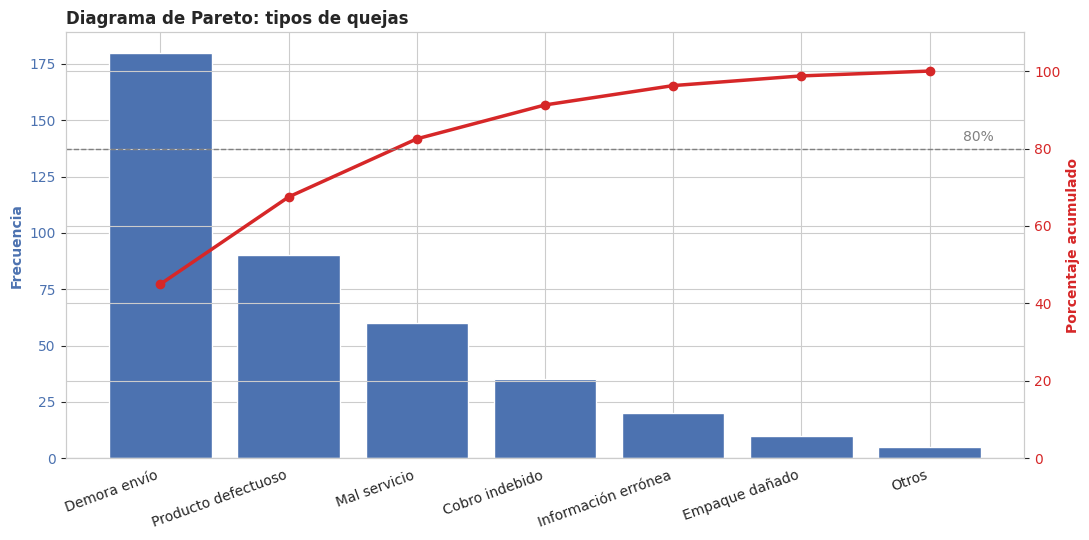

In [16]:
# Datos: quejas por tipo (ya ordenadas de mayor a menor)
tipos = ['Demora envío', 'Producto defectuoso', 'Mal servicio',
         'Cobro indebido', 'Información errónea', 'Empaque dañado',
         'Otros']
frecuencias = [180, 90, 60, 35, 20, 10, 5]

# Calcular porcentaje acumulado
df_pareto = pd.DataFrame({'tipo': tipos, 'frec': frecuencias})
df_pareto['acumulado_pct'] = df_pareto['frec'].cumsum() / df_pareto['frec'].sum() * 100

fig, ax1 = plt.subplots(figsize=(11, 5.5))

# Eje izquierdo: barras con frecuencias
barras = ax1.bar(df_pareto['tipo'], df_pareto['frec'],
                 color='#4c72b0', edgecolor='white')
ax1.set_ylabel('Frecuencia', color='#4c72b0', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#4c72b0')
ax1.set_xticklabels(df_pareto['tipo'], rotation=20, ha='right')

# Eje derecho: línea con porcentaje acumulado
ax2 = ax1.twinx()
ax2.plot(df_pareto['tipo'], df_pareto['acumulado_pct'],
         color='#d62728', marker='o', linewidth=2.5)
ax2.set_ylabel('Porcentaje acumulado', color='#d62728', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#d62728')
ax2.set_ylim(0, 110)

# Línea de referencia al 80%
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.text(len(tipos) - 0.5, 82, '80%', color='gray', ha='right')

ax1.set_title('Diagrama de Pareto: tipos de quejas', loc='left')

plt.tight_layout()
plt.show()

**Interpretación:** Las dos primeras causas (demora de envío + producto defectuoso) ya superan el 65% de las quejas. Atacar esas dos resolvería la mayoría de los problemas. Eso es la **regla de Pareto** en acción.

### 6.2 Hexbin plot

**¿Qué es?** Alternativa al scatter plot cuando hay tantísimos puntos que se superponen. Divide el plano en hexágonos y colorea cada uno según cuántos puntos contiene.

**¿Cuándo usarlo?** Con miles o millones de observaciones, donde un scatter sería una mancha negra ininteligible.

**Ejemplo:** relación entre dos mediciones de sensores con 10.000 lecturas.

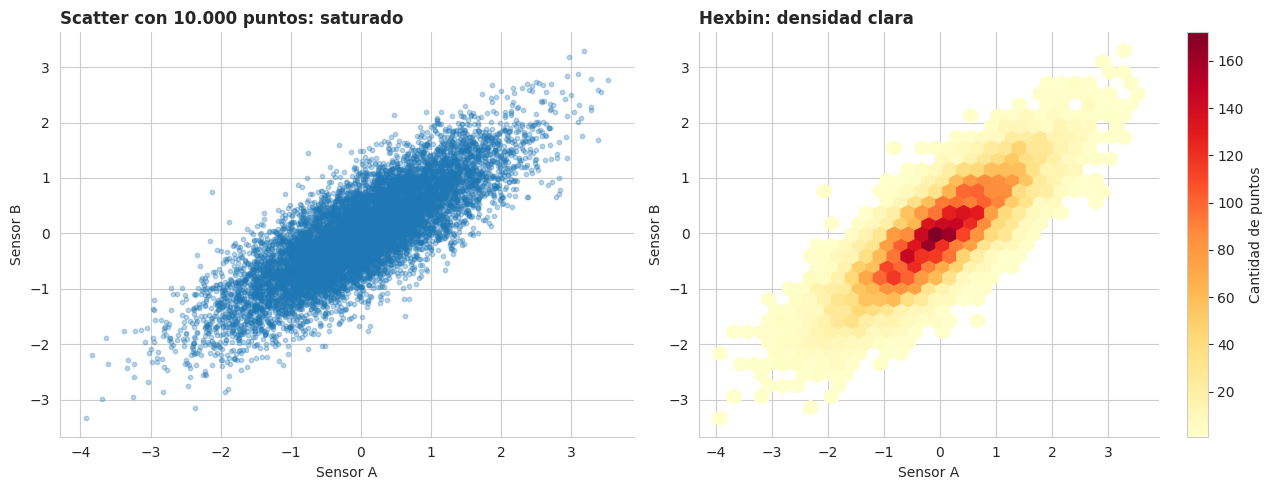

In [17]:
# Generar 10.000 puntos correlacionados
n = 10000
x = np.random.normal(0, 1, n)
y = x * 0.7 + np.random.normal(0, 0.5, n)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter clásico: queda saturado
axes[0].scatter(x, y, alpha=0.3, s=10)
axes[0].set_title('Scatter con 10.000 puntos: saturado', loc='left')
axes[0].set_xlabel('Sensor A')
axes[0].set_ylabel('Sensor B')

# Hexbin: la densidad se ve clara
hb = axes[1].hexbin(x, y, gridsize=30, cmap='YlOrRd', mincnt=1)
axes[1].set_title('Hexbin: densidad clara', loc='left')
axes[1].set_xlabel('Sensor A')
axes[1].set_ylabel('Sensor B')
fig.colorbar(hb, ax=axes[1], label='Cantidad de puntos')

for ax in axes:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretación:** El scatter de la izquierda esconde la verdadera concentración de datos; el hexbin muestra con claridad dónde están la mayoría de las observaciones (zona roja central).

### 6.3 Calendar heatmap (estilo GitHub)

**¿Qué es?** Una grilla con un color por día del año. Inspirado en el famoso "contributions graph" de GitHub.

**¿Cuándo usarlo?** Para ver patrones temporales: actividad diaria, ventas por día, asistencias, picos por día de semana o estacionalidad.

**Ejemplo:** actividad diaria de un usuario durante un año.

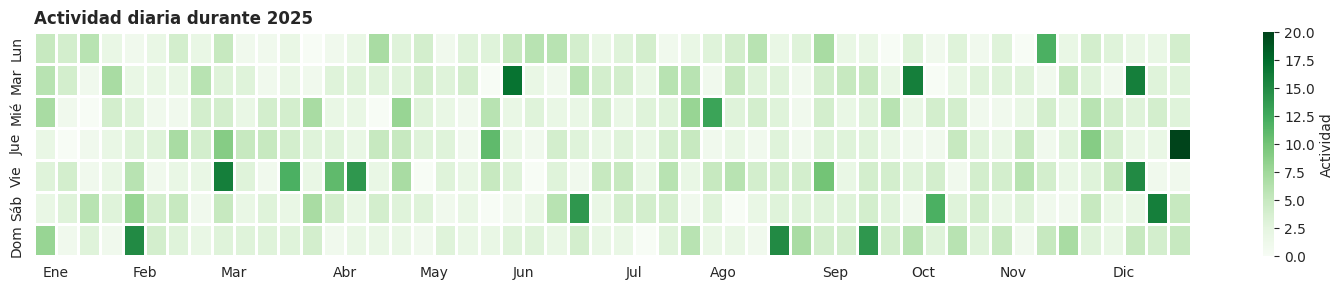

In [18]:
# Generar 365 días de actividad (con tendencia y ruido)
fechas    = pd.date_range('2025-01-01', '2025-12-31')
actividad = np.random.poisson(lam=3, size=len(fechas))

# Simular días de mucha actividad (eventos especiales)
dias_pico = np.random.choice(len(fechas), size=20, replace=False)
actividad[dias_pico] += np.random.randint(5, 15, size=20)

df_cal = pd.DataFrame({'fecha': fechas, 'actividad': actividad})
df_cal['semana'] = df_cal['fecha'].dt.isocalendar().week
df_cal['dia_semana'] = df_cal['fecha'].dt.dayofweek   # 0=lunes, 6=domingo
df_cal['mes'] = df_cal['fecha'].dt.month

# Pivotar: filas = día de la semana, columnas = semana del año
matriz = df_cal.pivot_table(index='dia_semana', columns='semana',
                             values='actividad', aggfunc='first')

fig, ax = plt.subplots(figsize=(15, 3))

sns.heatmap(matriz,
            cmap='Greens',
            cbar_kws={'label': 'Actividad'},
            linewidths=1, linecolor='white',
            yticklabels=['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom'],
            xticklabels=False,
            ax=ax)

# Etiquetas de meses en el eje X
primer_dia_mes = df_cal.groupby('mes').first().reset_index()
ax.set_xticks(primer_dia_mes['semana'])
ax.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                    'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])

ax.set_title('Actividad diaria durante 2025', loc='left')
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

**Interpretación:** Cada celda es un día. Los verdes más oscuros son días de mayor actividad. De un vistazo se identifican rachas, días "muertos" y patrones por día de la semana.

---
## Resumen: cuándo usar cada gráfico avanzado

| Necesidad | Gráfico recomendado |
|---|---|
| Comparar valores entre regiones geográficas | Mapa coroplético |
| Mostrar ubicaciones específicas con magnitud | Mapa de puntos |
| Ver concentración de muchísimos eventos georreferenciados | Mapa de densidad |
| Mostrar partes de un todo con jerarquía | Treemap o Sunburst |
| Comparar distribuciones (ver la forma, no solo los cuartiles) | Violin plot |
| Comparar muchas distribuciones de forma compacta | Ridgeline plot |
| Comparar perfiles multi-dimensionales (5-8 variables) | Radar chart |
| Mostrar 3 o 4 variables a la vez | Bubble chart |
| Visualizar flujos entre etapas o categorías | Sankey diagram |
| Descomponer un valor en sumas/restas paso a paso | Waterfall |
| Mostrar tasas de conversión por etapas | Funnel |
| Aplicar la regla 80/20 (control de calidad) | Diagrama de Pareto |
| Reemplazar un scatter saturado de puntos | Hexbin |
| Ver patrones temporales día a día | Calendar heatmap |

---

### Recomendaciones finales

1. **No uses un gráfico raro por moda.** El criterio sigue siendo: ¿es la mejor forma de responder mi pregunta?
2. **Más vistoso no significa más claro.** Un buen gráfico de barras casi siempre le gana a uno fancy mal usado.
3. **Plotly y los gráficos interactivos** brillan en informes web y dashboards. Para imprimir o exportar PDF, prefiere matplotlib.
4. **Documenta tus visualizaciones.** Un título claro y una nota interpretativa valen más que cualquier efecto visual.

---

**Universidad Autónoma de Manizales — Educación Continuada**

*Sergio Alejandro Holguín García*